# AMR Drug Repurposing — 02: Modeling

Trains Random Forest and deep MLP on ECFP4 fingerprints, evaluates both, screens FDA-approved drugs, computes SHAP attributions, and optionally fine-tunes ChemBERTa.

## Paths

In [1]:
from pathlib import Path
import os

PROJECT_ROOT = Path(__file__).resolve().parents[1] if '__file__' in dir() else Path.cwd().parent
# When running from notebooks/ dir, parent is the project root
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = Path.cwd()

DATA_DIR  = PROJECT_ROOT / 'data'
CKPT_DIR  = PROJECT_ROOT / 'checkpoints'
FIG_DIR   = PROJECT_ROOT / 'figures'

for d in [DATA_DIR, CKPT_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"DATA_DIR     : {DATA_DIR}")
print(f"CKPT_DIR     : {CKPT_DIR}")
print(f"FIG_DIR      : {FIG_DIR}")

PROJECT_ROOT : /Users/jubayer/Projects/amr_drug_repurposing
DATA_DIR     : /Users/jubayer/Projects/amr_drug_repurposing/data
CKPT_DIR     : /Users/jubayer/Projects/amr_drug_repurposing/checkpoints
FIG_DIR      : /Users/jubayer/Projects/amr_drug_repurposing/figures


## Imports

In [2]:
import asyncio, ast, httpx, json, time, warnings, gc
import nest_asyncio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Draw, QED, rdMolDescriptors
from rdkit.Chem.inchi import MolToInchi, InchiToInchiKey
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, confusion_matrix,
                              roc_curve, precision_recall_curve)
from sklearn.utils.class_weight import compute_sample_weight

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

warnings.filterwarnings('ignore')
nest_asyncio.apply()

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('mps'  if torch.backends.mps.is_available()
                  else 'cuda' if torch.cuda.is_available() else 'cpu')

# ── Memory & thermal management 
def free_memory(*objs):
    for o in objs:
        try: del o
        except: pass
    gc.collect()
    if torch.backends.mps.is_available():   torch.mps.empty_cache()
    elif torch.cuda.is_available():          torch.cuda.empty_cache()

def cool_down(seconds=8, label=""):
    if label: print(f"  [cool-down] {label} ({seconds}s)")
    time.sleep(seconds)

# Conservative batch size — MPS shares RAM with OS; keep pressure low
BATCH_SIZE = 128 if device.type in ('mps', 'cpu') else 256
print(f"Device: {device}  |  Batch size: {BATCH_SIZE}")

Device: mps  |  Batch size: 128


## Load pre-computed fingerprints & molecule-level split

**Fix 1:** Row-level random splitting allows the same molecule (tested on multiple organisms) to appear in both train and test, inflating reported metrics. Split on unique molecule IDs using a majority-vote activity label, then mask rows.

In [3]:
X        = np.load(DATA_DIR / 'X_ecfp.npy')
y        = np.load(DATA_DIR / 'y_labels.npy')
df_clean = pd.read_csv(DATA_DIR / 'eskape_clean.csv')

# Reconstruct per-fingerprint alignment (mirrors nb01 fingerprint loop order)
_valid_mask  = df_clean['canonical_smiles'].apply(
    lambda s: isinstance(s, str) and Chem.MolFromSmiles(s) is not None)
df_fp = df_clean[_valid_mask].reset_index(drop=True)
assert len(df_fp) == len(X),     f"Fingerprint/clean-data mismatch: X={len(X)}, valid_smiles={len(df_fp)}"

organism_arr = df_fp['target_organism'].values

# ── Molecule-level split (Fix 1) 
# Assign each unique molecule a majority-vote activity label, split on molecules,
# then map back to rows. This guarantees zero molecule overlap between train/test.
mol_label = (df_fp.groupby('molecule_chembl_id')['active']
               .agg(lambda x: int(x.mean() >= 0.5)))
mol_ids   = mol_label.index.to_numpy().astype(str)
mol_y     = mol_label.to_numpy().astype(int)

train_mols, test_mols = train_test_split(
    mol_ids, test_size=0.2, random_state=SEED, stratify=mol_y)

train_mols_set = set(train_mols)
test_mols_set  = set(test_mols)

# Boolean row masks
train_mask = df_fp['molecule_chembl_id'].astype(str).isin(train_mols_set).values
test_mask  = df_fp['molecule_chembl_id'].astype(str).isin(test_mols_set).values

X_train, X_test   = X[train_mask],            X[test_mask]
y_train, y_test   = y[train_mask],            y[test_mask]
org_train, org_test = organism_arr[train_mask], organism_arr[test_mask]

# Verify zero molecule overlap
overlap = train_mols_set & test_mols_set
assert len(overlap) == 0, f"Molecule overlap detected: {len(overlap)} molecules"

print(f"Unique molecules total : {len(mol_ids):,}")
print(f"Train rows : {X_train.shape[0]:,}  ({len(train_mols):,} unique molecules)")
print(f"Test  rows : {X_test.shape[0]:,}   ({len(test_mols):,} unique molecules)")
print(f"Molecule overlap: {len(overlap)} (confirmed zero leakage)")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test  positive rate: {y_test.mean():.3f}")

# Save masks so ChemBERTa cell can apply the same molecule-level split
np.save(DATA_DIR / 'train_mask.npy', train_mask)
np.save(DATA_DIR / 'test_mask.npy',  test_mask)

Unique molecules total : 48,153
Train rows : 57,341  (38,522 unique molecules)
Test  rows : 14,282   (9,631 unique molecules)
Molecule overlap: 0 (confirmed zero leakage)
Train positive rate: 0.431
Test  positive rate: 0.430


## Random Forest baseline

In [4]:
print("Training Random Forest (300 trees)...")
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    class_weight='balanced', n_jobs=-1, random_state=SEED
)
# Fit RF on full training set, then calibrate on held-out calibration split
# (isotonic calibration corrects RF overconfidence; needed for reliable repurposing scores)
X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train)

rf_base = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    class_weight='balanced', n_jobs=-1, random_state=SEED)
rf_base.fit(X_fit, y_fit)

rf_cal = CalibratedClassifierCV(rf_base, method='isotonic', cv=None)
rf_cal.fit(X_cal, y_cal)

# Also fit rf on full X_train — used by SHAP and organism-specific models
rf.fit(X_train, y_train)

rf_prob = rf_cal.predict_proba(X_test)[:, 1]
rf_pred = (rf_prob >= 0.5).astype(int)
rf_roc  = roc_auc_score(y_test, rf_prob)
rf_prc  = average_precision_score(y_test, rf_prob)

print(f"RF done in {time.time()-t0:.0f}s  |  ROC-AUC: {rf_roc:.4f}  PRC-AUC: {rf_prc:.4f}")
print(classification_report(y_test, rf_pred, target_names=['Inactive','Active']))
baseline_results = {'roc_auc': rf_roc, 'prc_auc': rf_prc}
cool_down(5, "post-RF training")

Training Random Forest (300 trees)...
RF done in 24s  |  ROC-AUC: 0.8766  PRC-AUC: 0.8559
              precision    recall  f1-score   support

    Inactive       0.81      0.84      0.82      8140
      Active       0.77      0.74      0.75      6142

    accuracy                           0.79     14282
   macro avg       0.79      0.79      0.79     14282
weighted avg       0.79      0.79      0.79     14282

  [cool-down] post-RF training (5s)


## Deep MLP architecture

In [5]:
class FingerprintDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


class AntibacterialMLP(nn.Module):
    def __init__(self, input_dim=2048, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(1024, 512),       nn.BatchNorm1d(512),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256),        nn.BatchNorm1d(256),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),        nn.BatchNorm1d(128),  nn.ReLU(), nn.Dropout(dropout * 0.5),
            nn.Linear(128, 1),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x): return self.net(x).squeeze(-1)


n_neg, n_pos = (y_train == 0).sum(), (y_train == 1).sum()
pos_weight    = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
sample_weights = np.where(y_train == 1, n_neg / n_pos, 1.0)
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(y_train), replacement=True)

# num_workers=0: required for MPS; prevents file-descriptor leaks on CPU too
train_loader = DataLoader(FingerprintDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
test_loader  = DataLoader(FingerprintDataset(X_test,  y_test),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model     = AntibacterialMLP(input_dim=X_train.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 2,791,169


## Training loop with checkpointing

In [6]:
CKPT_PATH   = CKPT_DIR / 'best_mlp.pt'
EPOCHS, LOG_EVERY = 60, 5

def evaluate(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            logits = model(X_b.to(device)).cpu()
            all_logits.append(logits); all_labels.append(y_b)
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    proba  = 1 / (1 + np.exp(-logits))
    return roc_auc_score(labels, proba), average_precision_score(labels, proba)

start_epoch, best_auc = 0, 0.0
if CKPT_PATH.exists():
    ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    start_epoch = ckpt['epoch'] + 1
    best_auc    = ckpt['best_auc']
    print(f"Resumed from epoch {ckpt['epoch']}  |  best ROC-AUC: {best_auc:.4f}")

train_losses, val_aucs, val_prcs = [], [], []
print(f"Training on {device} for {EPOCHS} epochs (batch={BATCH_SIZE})...")

for epoch in range(start_epoch, EPOCHS):
    model.train()
    epoch_loss = 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    roc, prc = evaluate(model, test_loader)
    val_aucs.append(roc); val_prcs.append(prc)

    if roc > best_auc:
        best_auc = roc
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'optimizer_state': optimizer.state_dict(), 'best_auc': best_auc}, CKPT_PATH)
        marker = " ← best"
    else:
        marker = ""

    if (epoch + 1) % LOG_EVERY == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss: {avg_loss:.4f} | "
              f"ROC-AUC: {roc:.4f} | PRC-AUC: {prc:.4f}{marker}")

    if (epoch + 1) % 10 == 0:
        free_memory()

print(f"\nBest ROC-AUC: {best_auc:.4f}")

# Save training history so nb03 can load it standalone (without rerunning training)
np.savez(
    CKPT_DIR / 'training_history.npz',
    train_losses=np.array(train_losses),
    val_aucs=np.array(val_aucs),
    val_prcs=np.array(val_prcs),
    baseline_results=np.array(baseline_results),
)
print(f"Training history saved -> checkpoints/training_history.npz")
cool_down(10, "post-MLP training")

Resumed from epoch 21  |  best ROC-AUC: 0.9693
Training on mps for 60 epochs (batch=128)...
Epoch  25/60 | Loss: 0.2325 | ROC-AUC: 0.9629 | PRC-AUC: 0.9521
Epoch  30/60 | Loss: 0.2047 | ROC-AUC: 0.9590 | PRC-AUC: 0.9477
Epoch  35/60 | Loss: 0.1905 | ROC-AUC: 0.9551 | PRC-AUC: 0.9428
Epoch  40/60 | Loss: 0.1761 | ROC-AUC: 0.9540 | PRC-AUC: 0.9412
Epoch  45/60 | Loss: 0.1669 | ROC-AUC: 0.9530 | PRC-AUC: 0.9401
Epoch  50/60 | Loss: 0.1601 | ROC-AUC: 0.9523 | PRC-AUC: 0.9389
Epoch  55/60 | Loss: 0.1528 | ROC-AUC: 0.9513 | PRC-AUC: 0.9379
Epoch  60/60 | Loss: 0.1485 | ROC-AUC: 0.9529 | PRC-AUC: 0.9402

Best ROC-AUC: 0.9693
Training history saved -> checkpoints/training_history.npz
  [cool-down] post-MLP training (10s)


## Training curves

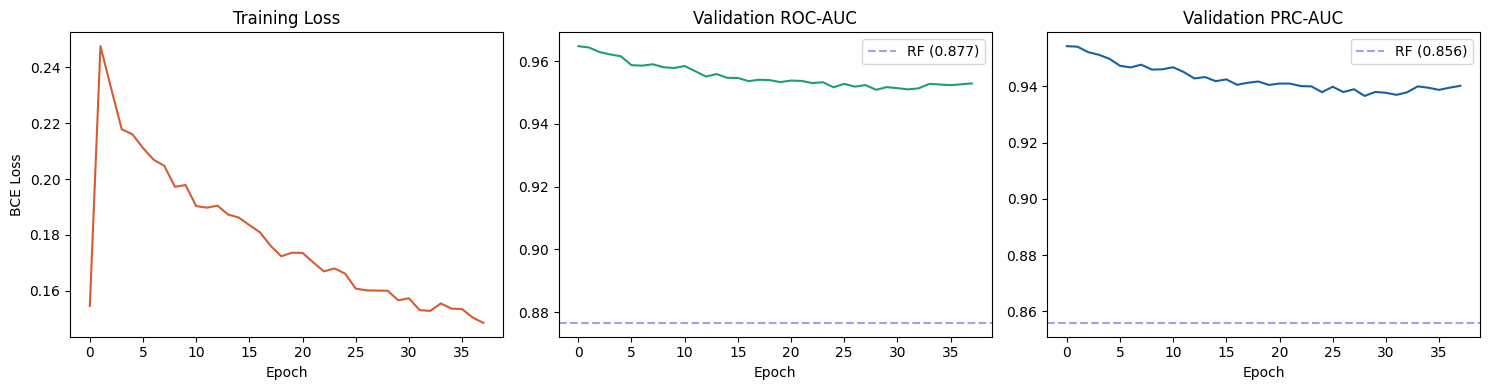

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_losses, color='#D85A30', lw=1.5)
axes[0].set(title='Training Loss', xlabel='Epoch', ylabel='BCE Loss')

axes[1].plot(val_aucs, color='#1D9E75', lw=1.5)
axes[1].axhline(baseline_results['roc_auc'], color='#7F77DD', ls='--', alpha=0.7,
                label=f"RF ({baseline_results['roc_auc']:.3f})")
axes[1].set(title='Validation ROC-AUC', xlabel='Epoch')
axes[1].legend()

axes[2].plot(val_prcs, color='#185FA5', lw=1.5)
axes[2].axhline(baseline_results['prc_auc'], color='#7F77DD', ls='--', alpha=0.7,
                label=f"RF ({baseline_results['prc_auc']:.3f})")
axes[2].set(title='Validation PRC-AUC', xlabel='Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'training_curves.png', dpi=150)
plt.show()

## Final evaluation on test set

In [8]:
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.eval()

all_proba, all_labels = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        logits = model(X_b.to(device)).cpu().numpy().flatten()
        all_proba.extend(1 / (1 + np.exp(-logits)))
        all_labels.extend(y_b.numpy())

y_prob = np.array(all_proba)
y_true = np.array(all_labels)
y_pred = (y_prob >= 0.5).astype(int)

mlp_roc = roc_auc_score(y_true, y_prob)
mlp_prc = average_precision_score(y_true, y_prob)

print(f"MLP  ROC-AUC: {mlp_roc:.4f}  |  PRC-AUC: {mlp_prc:.4f}")
print(classification_report(y_true, y_pred, target_names=['Inactive','Active']))

MLP  ROC-AUC: 0.9693  |  PRC-AUC: 0.9601
              precision    recall  f1-score   support

    Inactive       0.94      0.88      0.91      8140
      Active       0.85      0.92      0.88      6142

    accuracy                           0.90     14282
   macro avg       0.89      0.90      0.90     14282
weighted avg       0.90      0.90      0.90     14282



## ROC, PR curves, and confusion matrix

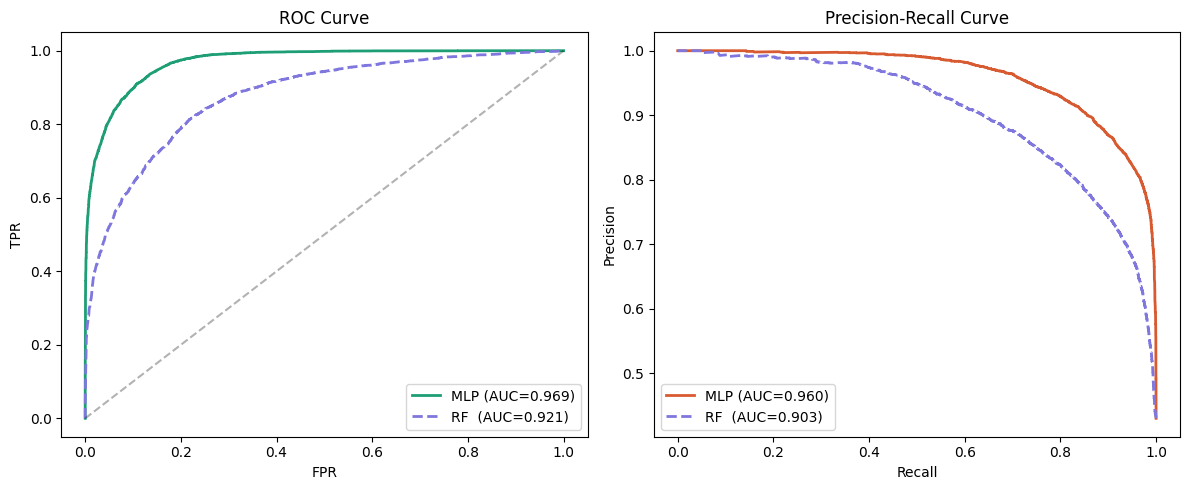

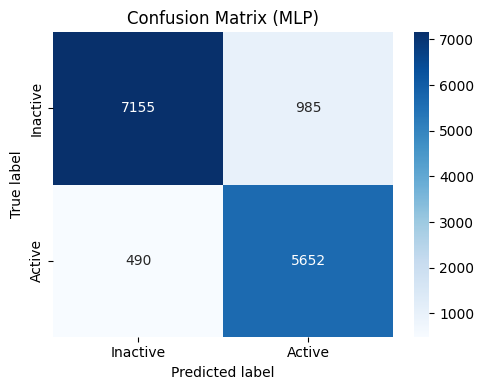

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y_true, y_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_cal.predict_proba(X_test)[:, 1])
axes[0].plot(fpr,    tpr,    color='#1D9E75', lw=2, label=f'MLP (AUC={mlp_roc:.3f})')
axes[0].plot(fpr_rf, tpr_rf, color='#7F77DD', lw=2, ls='--',
             label=f'RF  (AUC={roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.3f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.3)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_true, y_prob)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, rf.predict_proba(X_test)[:, 1])
axes[1].plot(rec,    prec,    color='#D85A30', lw=2, label=f'MLP (AUC={mlp_prc:.3f})')
axes[1].plot(rec_rf, prec_rf, color='#7F77DD', lw=2, ls='--',
             label=f'RF  (AUC={average_precision_score(y_test, rf.predict_proba(X_test)[:,1]):.3f})')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'evaluation_curves.png', dpi=150)
plt.show()

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Inactive','Active'], yticklabels=['Inactive','Active'])
ax.set(title='Confusion Matrix (MLP)', ylabel='True label', xlabel='Predicted label')
plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

## Fetch FDA-approved drugs for repurposing screen

**Fix 2:** Parse `atc_classifications` column directly from ChEMBL response. Exclude ATC J01 (antibacterials) **and J04** (anti-mycobacterials). Add `cef`/`ceph` cephalosporin stems missing from previous keyword list.

In [10]:
BASE_URL = "https://www.ebi.ac.uk/chembl/api/data"

async def fetch_page(client, url, params, retries=3):
    for attempt in range(retries):
        try:
            r = await client.get(url, params=params, timeout=60)
            r.raise_for_status()
            return r.json()
        except Exception as e:
            if attempt == retries - 1:
                print(f"  Failed: {e}"); return None
            await asyncio.sleep(2 ** attempt)

async def fetch_approved_drugs():
    params = {
        "max_phase": 4, "molecule_type": "Small molecule",
        "limit": 1000, "offset": 0, "format": "json",
        "fields": "molecule_chembl_id,pref_name,max_phase,molecule_structures,"
                  "indication_class,atc_classifications",
    }
    records = []
    limits  = httpx.Limits(max_connections=5, max_keepalive_connections=5)
    async with httpx.AsyncClient(limits=limits) as client:
        data  = await fetch_page(client, f"{BASE_URL}/molecule.json", params)
        total = data["page_meta"]["total_count"]
        records.extend(data["molecules"])
        print(f"Total approved small-molecule drugs: {total}")
        tasks = [fetch_page(client, f"{BASE_URL}/molecule.json", {**params, "offset": o})
                 for o in range(1000, total, 1000)]
        for p in await asyncio.gather(*tasks):
            if p: records.extend(p["molecules"])
    return records

APPROVED_PATH = DATA_DIR / 'approved_drugs.csv'

if APPROVED_PATH.exists() and APPROVED_PATH.stat().st_size > 0:
    df_drugs = pd.read_csv(APPROVED_PATH)
    if 'canonical_smiles' not in df_drugs.columns:
        df_drugs = pd.DataFrame()
    else:
        print(f"Loaded {len(df_drugs):,} approved drugs from cache")
else:
    df_drugs = pd.DataFrame()

if df_drugs.empty:
    records  = await fetch_approved_drugs()
    df_drugs = pd.DataFrame(records)
    if 'molecule_structures' in df_drugs.columns:
        df_drugs['canonical_smiles'] = df_drugs['molecule_structures'].apply(
            lambda x: x.get('canonical_smiles') if isinstance(x, dict) else None)
    df_drugs.to_csv(APPROVED_PATH, index=False)

for col in ('indication_class', 'atc_classifications', 'canonical_smiles'):
    if col not in df_drugs.columns:
        df_drugs[col] = ""

df_drugs = df_drugs.dropna(subset=['canonical_smiles'])
df_drugs = df_drugs[df_drugs['canonical_smiles'].str.len() > 5].copy()

# ── Three-layer antibiotic exclusion ─────────────────────────────────────────
# Layer 1 — ATC J01 (antibacterials systemic) + J04 (anti-mycobacterials)
def parse_atc(val):
    if pd.isna(val) or val == '' or val == '[]': return []
    try:
        parsed = ast.literal_eval(str(val)) if isinstance(val, str) else list(val)
        return [str(x) for x in parsed]
    except Exception:
        return []

df_drugs['atc_list'] = df_drugs['atc_classifications'].apply(parse_atc)
ANTIBIOTIC_ATC = ('J01', 'J04')
_atc_mask = df_drugs['atc_list'].apply(
    lambda codes: any(c.startswith(ANTIBIOTIC_ATC) for c in codes))

# Layer 2 — indication_class keywords
_ind_kw   = ['antibiotic','antibacterial','antimicrobial','beta-lactam',
              'penicillin','cephalosporin','macrolide','quinolone','aminoglycoside',
              'antitubercular','antimycobacterial']
_ind_mask = df_drugs['indication_class'].fillna('').str.lower().apply(
    lambda x: any(kw in x for kw in _ind_kw))

# Layer 3 — INN name stems + explicit compounds missed by layers 1-2
# Covers: penicillins, cephalosporins, carbacephems (loracarbef), carbapenems,
#         monobactams, tetracyclines, aminoglycosides, macrolides, fluoroquinolones,
#         oxazolidinones, glycopeptides, lipopeptides, anti-TB, nitroimidazoles, etc.
_name_kw  = [
    # beta-lactam stems
    'floxacin','oxacin','cillin','cyclin','mycin','penem','bactam',
    'cef','ceph',                                    # cephalosporins
    'carbef','carbaceph','loracarbef',               # carbacephems (e.g. loracarbef)
    # sulfonamides / antifolates used as antibiotics
    'sulfa','sulfameth','trimethoprim',
    # anti-TB
    'isoniazid','rifamp','rifabutin','ethambutol',
    'pretomanid','delamanid','bedaquiline',
    # other systemic antibacterials
    'metronidazole','vancomycin','linezolid','tedizolid','daptomycin',
    'fosfomycin','colistin','polymyxin','chloramphenicol','nitrofurantoin',
    'clindamycin','azithromycin','clarithromycin','erythromycin',
    'tobramycin','gentamicin','amikacin','plazomicin','streptomycin',
    'neomycin','kanamycin','netilmicin','spectinomycin',
    'tetracycline','doxycycline','minocycline','tigecycline','omadacycline',
    'meropenem','imipenem','ertapenem','aztreonam',
    'quinupristin','dalfopristin','oritavancin','dalbavancin','telavancin',
    'lefamulin','fidaxomicin','retapamulin','mupirocin','bacitracin',
    'rifaximin','nalidixic','novobiocin','fusidic',
]
_name_mask = df_drugs['pref_name'].fillna('').str.lower().apply(
    lambda x: any(kw in x for kw in _name_kw))

antibiotic_mask = _atc_mask | _ind_mask | _name_mask
df_drugs_nonabx = df_drugs[~antibiotic_mask].copy().reset_index(drop=True)

print(f"Approved drugs total              : {len(df_drugs):,}")
print(f"  Excluded via ATC J01/J04        : {_atc_mask.sum():,}")
print(f"  Excluded via indication_class   : {(~_atc_mask & _ind_mask).sum():,}")
print(f"  Excluded via INN name           : {(~_atc_mask & ~_ind_mask & _name_mask).sum():,}")
print(f"Non-antibiotic drugs remaining    : {len(df_drugs_nonabx):,}")

Loaded 3,280 approved drugs from cache
Approved drugs total              : 3,112
  Excluded via ATC J01/J04        : 146
  Excluded via indication_class   : 0
  Excluded via INN name           : 217
Non-antibiotic drugs remaining    : 2,749


## Repurposing screen

**Fix 3:** Deduplicate salt/solvate forms using InChIKey connectivity layer before screening (removes duplicate entries like LEVOFLOXACIN / LEVOFLOXACIN ANHYDROUS / LEVOFLOXACIN HYDROCHLORIDE). **Fix 4:** Screen uses the deduplicated set.

In [11]:
def smiles_to_ecfp(smiles, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nbits))

def smiles_to_inchikey_parent(smiles):
    """Return the connectivity block of InChIKey (salt/solvate-invariant)."""
    if not isinstance(smiles, str): return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    try:
        inchi = MolToInchi(mol)
        if not inchi: return None
        key = InchiToInchiKey(inchi)
        if not key: return None
        return key.split('-')[0]   # first 14-char block = connectivity layer
    except Exception:
        return None

def compute_admet(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    mw    = Descriptors.MolWt(mol)
    logp  = Descriptors.MolLogP(mol)
    hbd   = rdMolDescriptors.CalcNumHBD(mol)
    hba   = rdMolDescriptors.CalcNumHBA(mol)
    tpsa  = Descriptors.TPSA(mol)
    rot   = rdMolDescriptors.CalcNumRotatableBonds(mol)
    rings = rdMolDescriptors.CalcNumRings(mol)
    arom  = rdMolDescriptors.CalcNumAromaticRings(mol)
    qed_v = QED.qed(mol)
    return dict(mw=round(mw,1), logp=round(logp,2), hbd=hbd, hba=hba,
                tpsa=round(tpsa,1), rot_bonds=rot, rings=rings, arom_rings=arom,
                qed=round(qed_v,3),
                lipinski=int(mw<=500 and logp<=5 and hbd<=5 and hba<=10),
                veber=int(tpsa<=140 and rot<=10),
                drug_like=int(mw<=500 and logp<=5 and hbd<=5 and hba<=10
                              and tpsa<=140 and rot<=10))

# ── Fix 3: Deduplicate salt/solvate forms by InChIKey parent ─────────────────
print("Computing InChIKey parents (Fix 3: salt-form deduplication)...")
df_drugs_nonabx['inchikey_parent'] = df_drugs_nonabx['canonical_smiles'].apply(
    smiles_to_inchikey_parent)
df_drugs_nonabx = df_drugs_nonabx.dropna(subset=['inchikey_parent'])

# Keep alphabetically first name per parent (e.g. ATORVASTATIN not ATORVASTATIN CALCIUM)
df_screen = (df_drugs_nonabx.sort_values('pref_name')
                             .drop_duplicates(subset='inchikey_parent', keep='first')
                             .reset_index(drop=True))

print(f"Before deduplication : {len(df_drugs_nonabx):,} non-antibiotic drugs")
print(f"After deduplication  : {len(df_screen):,} unique parent structures")
print(f"Removed              : {len(df_drugs_nonabx)-len(df_screen):,} salt/solvate duplicates")

# ── Fix 4: Repurposing screen on deduplicated set ─────────────────────────────
print("\nFingerprinting + ADMET scoring deduplicated non-antibiotic drugs...")
screen_fps, screen_ids, screen_names = [], [], []
screen_smiles, screen_atc, screen_indication, admet_rows = [], [], [], []

for _, row in tqdm(df_screen.iterrows(), total=len(df_screen)):
    fp  = smiles_to_ecfp(row['canonical_smiles'])
    adm = compute_admet(row['canonical_smiles'])
    if fp is None or adm is None: continue
    screen_fps.append(fp)
    screen_ids.append(row['molecule_chembl_id'])
    screen_names.append(row.get('pref_name', 'Unknown'))
    screen_smiles.append(row['canonical_smiles'])
    screen_atc.append(str(row.get('atc_list', [])))
    screen_indication.append(str(row.get('indication_class', '')) or '')
    admet_rows.append(adm)

X_screen = np.array(screen_fps, dtype=np.float32)

# MLP inference
model.eval()
screen_probs_mlp = []
with torch.no_grad():
    for batch in DataLoader(torch.tensor(X_screen), batch_size=512,
                             shuffle=False, num_workers=0):
        logits = model(batch.to(device)).cpu().numpy().flatten()
        screen_probs_mlp.extend(1 / (1 + np.exp(-logits)))

rf_probs_screen = rf_cal.predict_proba(X_screen)[:, 1]
ensemble_probs  = (np.array(screen_probs_mlp) + rf_probs_screen) / 2

df_admet  = pd.DataFrame(admet_rows)
df_results = pd.DataFrame({
    'chembl_id':     screen_ids,
    'drug_name':     screen_names,
    'smiles':        screen_smiles,
    'atc_codes':     screen_atc,
    'indication':    screen_indication,
    'prob_mlp':      np.round(screen_probs_mlp, 4),
    'prob_rf':       np.round(rf_probs_screen,  4),
    'prob_ensemble': np.round(ensemble_probs,   4),
}).join(df_admet).sort_values('prob_ensemble', ascending=False).reset_index(drop=True)

df_results.to_csv(DATA_DIR / 'repurposing_candidates.csv', index=False)

df_druglike = df_results[df_results['drug_like'] == 1].copy()
print(f"\nScreened            : {len(df_results):,} unique parent structures")
print(f"Drug-like (Ro5+Veber): {len(df_druglike):,}")
print(f"p >= 0.9             : {(df_druglike.prob_ensemble>=0.9).sum()}")
print(f"p >= 0.8             : {(df_druglike.prob_ensemble>=0.8).sum()}")
print(f"\nTop 10 drug-like candidates:")
print(df_druglike[['drug_name','atc_codes','prob_ensemble','qed','mw','logp']].head(10).to_string(index=False))
free_memory()

Computing InChIKey parents (Fix 3: salt-form deduplication)...
Before deduplication : 2,749 non-antibiotic drugs
After deduplication  : 2,659 unique parent structures
Removed              : 90 salt/solvate duplicates

Fingerprinting + ADMET scoring deduplicated non-antibiotic drugs...


  0%|          | 0/2659 [00:00<?, ?it/s]


Screened            : 2,659 unique parent structures
Drug-like (Ro5+Veber): 1,700
p >= 0.9             : 0
p >= 0.8             : 0

Top 10 drug-like candidates:
              drug_name                                                          atc_codes  prob_ensemble   qed    mw  logp
             NITISINONE                                                        ['A16AX04']         0.6916 0.368 329.2  2.73
            INDACATEROL                                                        ['R03AC18']         0.6875 0.519 392.5  3.15
             CLIOQUINOL ['D09AA10', 'P01AA02', 'P01AA52', 'S02AA05', 'G01AC02', 'D08AH30']         0.6705 0.758 305.5  3.20
          ACETAZOLAMIDE                                                        ['S01EC01']         0.6693 0.632 222.3 -0.86
             SORIVUDINE                                                                 []         0.6674 0.527 349.1 -1.49
           NIROGACESTAT                                                        ['L01XX81']   

## Visualise top candidates

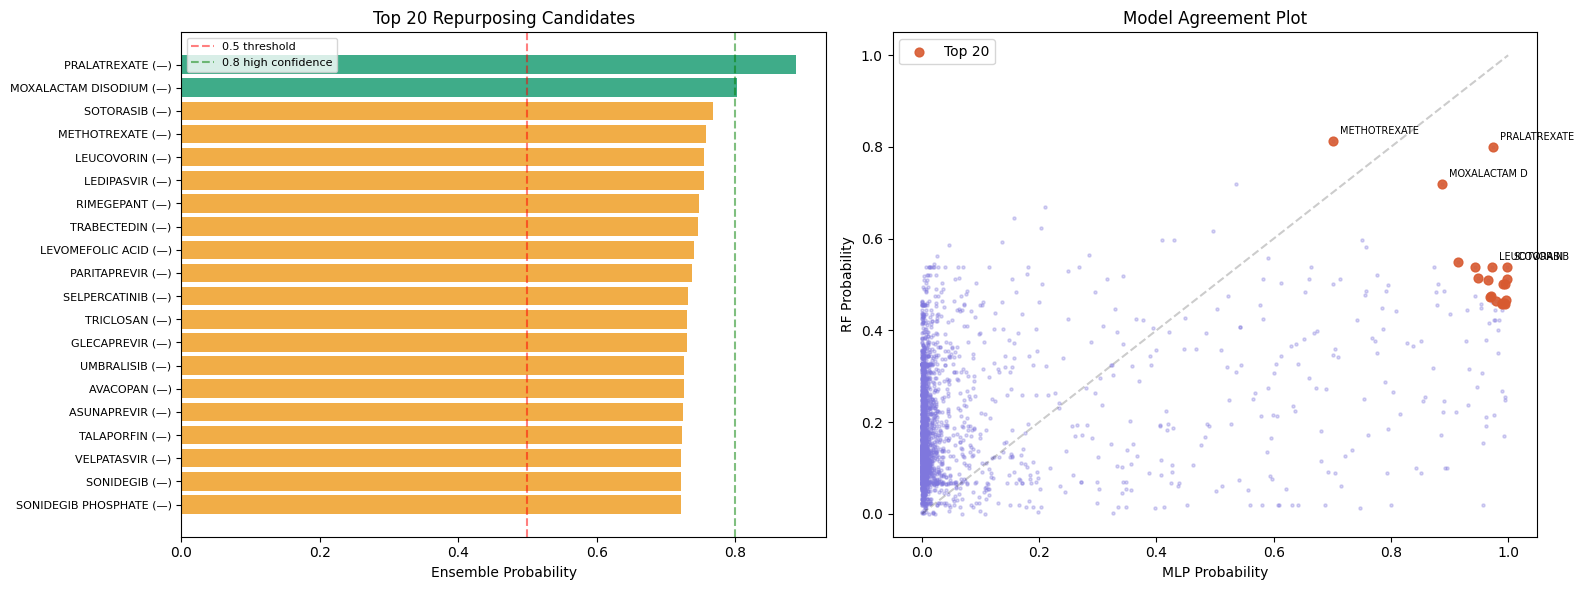

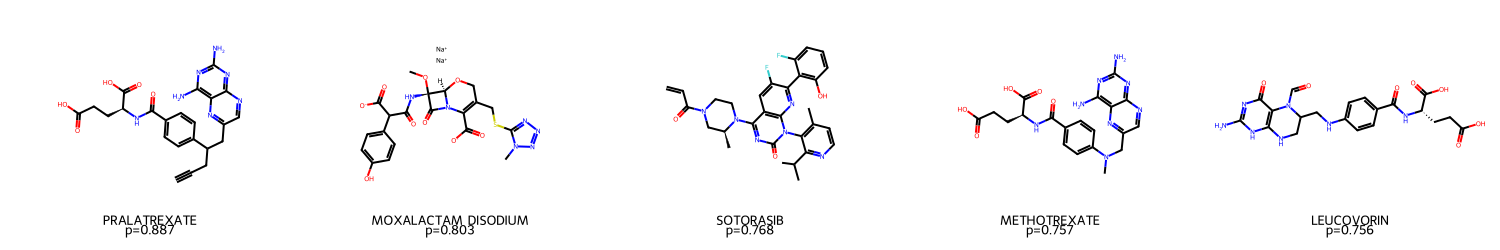

In [12]:
top20 = df_results.head(20).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#1D9E75' if p >= 0.8 else '#EF9F27' if p >= 0.6 else '#185FA5'
          for p in top20['prob_ensemble']]
axes[0].barh(range(len(top20)), top20['prob_ensemble'], color=colors, alpha=0.85)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels([f"{n} ({i})" for n, i in
                          zip(top20['drug_name'], top20.get('indication', pd.Series(['—']*len(top20))).replace('', '—').fillna('—').str[:25])],
                         fontsize=8)
axes[0].axvline(0.5, color='red',   ls='--', alpha=0.5, label='0.5 threshold')
axes[0].axvline(0.8, color='green', ls='--', alpha=0.5, label='0.8 high confidence')
axes[0].set_xlabel('Ensemble Probability')
axes[0].set_title('Top 20 Repurposing Candidates')
axes[0].legend(fontsize=8)
axes[0].invert_yaxis()

axes[1].scatter(df_results['prob_mlp'], df_results['prob_rf'], alpha=0.3, s=5, color='#7F77DD')
axes[1].scatter(top20['prob_mlp'],     top20['prob_rf'],       alpha=0.9, s=40, color='#D85A30',
                label='Top 20', zorder=5)
for _, row in top20.head(5).iterrows():
    axes[1].annotate(str(row['drug_name'])[:12], (row['prob_mlp'], row['prob_rf']),
                     fontsize=7, xytext=(5,5), textcoords='offset points')
axes[1].set(xlabel='MLP Probability', ylabel='RF Probability', title='Model Agreement Plot')
axes[1].legend()
axes[1].plot([0,1],[0,1],'k--', alpha=0.2)

plt.tight_layout()
plt.savefig(FIG_DIR / 'repurposing_candidates.png', dpi=150)
plt.show()

top5_smiles = top20['smiles'].head(5).tolist()
top5_names  = top20['drug_name'].head(5).tolist()
mols = [m for s in top5_smiles if (m := Chem.MolFromSmiles(s)) is not None]
if mols:
    img = Draw.MolsToGridImage(
        mols[:5], molsPerRow=5, subImgSize=(300, 250), useSVG=False,
        legends=[f"{n}\np={p:.3f}" for n, p in zip(top5_names, top20['prob_ensemble'].head(5))]
    )
    if hasattr(img, 'save'):
        img.save(str(FIG_DIR / 'top5_structures.png'))
    from IPython.display import display
    display(img)

## Organism-specific models

Train a Random Forest per ESKAPE pathogen to resolve organism-level activity. Organisms with fewer than 300 samples or fewer than 60 positives are skipped.

In [13]:
ORG_CKPT = DATA_DIR / 'organism_rf_results.csv'
ORG_MIN_SAMPLES  = 300
ORG_MIN_POSITIVE = 60

org_results = []
organisms   = np.unique(organism_arr)
print(f"Training organism-specific RF for {len(organisms)} pathogens...\n")

for org in organisms:
    mask    = organism_arr == org
    X_org   = X[mask];  y_org = y[mask]
    n_pos   = y_org.sum();  n_total = len(y_org)
    short   = ' '.join(org.split()[:2])

    if n_total < ORG_MIN_SAMPLES or n_pos < ORG_MIN_POSITIVE or (n_total - n_pos) < ORG_MIN_POSITIVE:
        print(f"  SKIP {short:<32s} n={n_total:5,}  pos={n_pos:4,}  (insufficient data)")
        org_results.append({'organism': org, 'n_total': n_total, 'n_active': int(n_pos),
                             'roc_auc': None, 'prc_auc': None, 'status': 'skipped'})
        continue

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_org, y_org, test_size=0.2, random_state=SEED, stratify=y_org)

    rf_org = RandomForestClassifier(
        n_estimators=200, min_samples_leaf=2,
        class_weight='balanced', n_jobs=-1, random_state=SEED)
    rf_org.fit(X_tr, y_tr)

    prob = rf_org.predict_proba(X_te)[:, 1]
    roc  = roc_auc_score(y_te, prob)
    prc  = average_precision_score(y_te, prob)

    print(f"  {short:<32s} n={n_total:5,}  pos={n_pos:4,}  ROC-AUC={roc:.3f}  PRC-AUC={prc:.3f}")
    org_results.append({'organism': org, 'n_total': n_total, 'n_active': int(n_pos),
                        'roc_auc': round(roc, 4), 'prc_auc': round(prc, 4), 'status': 'trained'})

    # Release memory immediately; don't accumulate 8 × 200-tree forests
    free_memory(rf_org, X_tr, X_te)
    cool_down(4, short[:20])

df_org = pd.DataFrame(org_results)
df_org.to_csv(ORG_CKPT, index=False)
print(f"\nOrganism results → {ORG_CKPT.name}")
print(df_org[['organism','n_total','n_active','roc_auc','prc_auc']].to_string(index=False))

Training organism-specific RF for 8 pathogens...

  Acinetobacter baumannii          n=11,734  pos=1,028  ROC-AUC=0.976  PRC-AUC=0.807
  [cool-down] Acinetobacter bauman (4s)
  Enterobacter cloacae             n=3,579  pos=2,189  ROC-AUC=0.944  PRC-AUC=0.964
  [cool-down] Enterobacter cloacae (4s)
  Enterococcus faecium             n=7,050  pos=3,882  ROC-AUC=0.888  PRC-AUC=0.900
  [cool-down] Enterococcus faecium (4s)
  Escherichia coli                 n=10,294  pos=5,247  ROC-AUC=0.947  PRC-AUC=0.953
  [cool-down] Escherichia coli (4s)
  Klebsiella pneumoniae            n=10,677  pos=4,074  ROC-AUC=0.940  PRC-AUC=0.920
  [cool-down] Klebsiella pneumonia (4s)
  Mycobacterium tuberculosis       n=10,377  pos=4,711  ROC-AUC=0.896  PRC-AUC=0.890
  [cool-down] Mycobacterium tuberc (4s)
  Pseudomonas aeruginosa           n=8,527  pos=3,170  ROC-AUC=0.942  PRC-AUC=0.918
  [cool-down] Pseudomonas aerugino (4s)
  Staphylococcus aureus            n=9,385  pos=6,572  ROC-AUC=0.922  PRC-AUC=0.96

## SHAP feature importance

In [14]:
import numpy as np
import shap

print("Computing safe interventional SHAP values...")

# 1. Clean input matrices
X_train_np = np.asarray(X_train, dtype=np.float64)
X_test_np  = np.asarray(X_test, dtype=np.float64)

assert X_train_np.ndim == 2
assert X_test_np.ndim == 2
assert X_train_np.shape[1] == rf.n_features_in_
assert X_test_np.shape[1] == rf.n_features_in_
assert np.isfinite(X_train_np).all()
assert np.isfinite(X_test_np).all()

# 2. Small background set
rng = np.random.default_rng(SEED)

n_bg = min(200, X_train_np.shape[0])
bg_idx = rng.choice(X_train_np.shape[0], size=n_bg, replace=False)
background = X_train_np[bg_idx]

# Samples to explain
X_explain = X_test_np[:300]

# 3. Safe SHAP explainer
explainer = shap.TreeExplainer(
    rf,
    data=background,
    feature_perturbation="interventional",
    model_output="probability"
)

shap_vals = explainer.shap_values(
    X_explain,
    check_additivity=False
)

# 4. Handle SHAP output format
if isinstance(shap_vals, list):
    # Older SHAP format: [class0, class1]
    sv = np.asarray(shap_vals[1])
elif isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 3:
    # Newer SHAP format: samples × features × classes
    sv = shap_vals[:, :, 1]
else:
    sv = np.asarray(shap_vals)

print("SHAP array shape:", sv.shape)

assert sv.ndim == 2, f"Expected 2D SHAP array, got {sv.shape}"
assert sv.shape == X_explain.shape, f"SHAP shape {sv.shape} != X shape {X_explain.shape}"
assert np.isfinite(sv).all(), "SHAP values contain NaN or infinite values"

# 5. Mean absolute SHAP ranking
mean_abs = np.abs(sv).mean(axis=0)
top_bits = np.argsort(mean_abs)[::-1][:20]

print("\nTop 20 ECFP4 bits by mean |SHAP|:")
for i, bit in enumerate(top_bits):
    print(f"Rank {i+1:02d}: bit_{bit:<5d} mean|SHAP| = {mean_abs[bit]:.6f}") 

Computing safe interventional SHAP values...


 99%|===================| 595/600 [01:45<00:00]        

SHAP array shape: (300, 2048)

Top 20 ECFP4 bits by mean |SHAP|:
Rank 01: bit_456   mean|SHAP| = 0.024258
Rank 02: bit_314   mean|SHAP| = 0.019545
Rank 03: bit_1047  mean|SHAP| = 0.017483
Rank 04: bit_525   mean|SHAP| = 0.016109
Rank 05: bit_1991  mean|SHAP| = 0.015180
Rank 06: bit_453   mean|SHAP| = 0.014657
Rank 07: bit_464   mean|SHAP| = 0.014356
Rank 08: bit_1019  mean|SHAP| = 0.014323
Rank 09: bit_699   mean|SHAP| = 0.011675
Rank 10: bit_1928  mean|SHAP| = 0.011513
Rank 11: bit_389   mean|SHAP| = 0.009945
Rank 12: bit_739   mean|SHAP| = 0.009245
Rank 13: bit_935   mean|SHAP| = 0.009074
Rank 14: bit_926   mean|SHAP| = 0.007713
Rank 15: bit_1917  mean|SHAP| = 0.007503
Rank 16: bit_407   mean|SHAP| = 0.007274
Rank 17: bit_1922  mean|SHAP| = 0.006680
Rank 18: bit_338   mean|SHAP| = 0.006562
Rank 19: bit_875   mean|SHAP| = 0.006380
Rank 20: bit_5     mean|SHAP| = 0.006365


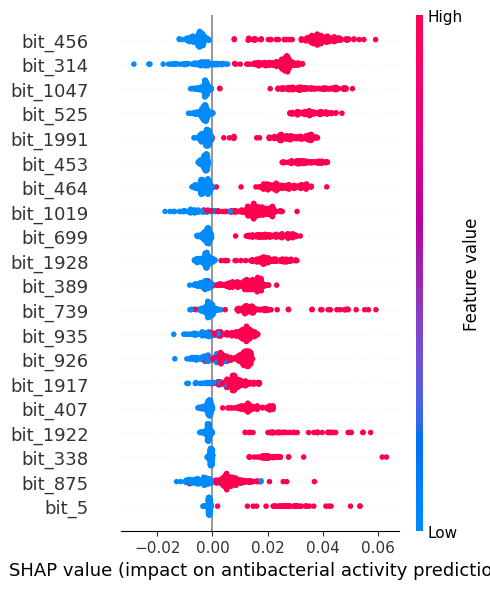

Saved shap_fixed.png / .svg


In [15]:
# Let SHAP create its own figure via plot_size — do NOT pre-create axes
shap.summary_plot(
    sv, X_explain,
    feature_names=[f"bit_{i}" for i in range(X_train.shape[1])],
    max_display=20,
    show=False,
    plot_size=(5.0, 6.0),
)
fig_shap = plt.gcf()
fig_shap.axes[0].set_xlabel("SHAP value (impact on antibacterial activity prediction)")
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_fixed.png', dpi=300, bbox_inches='tight')
plt.savefig(FIG_DIR / 'shap_fixed.svg', bbox_inches='tight')
plt.show()
print("Saved shap_fixed.png / .svg")

## ChemBERTa fine-tuning

Requires GPU. On Apple Silicon MPS is used but ChemBERTa fp16 needs MPS >= macOS 14.

In [16]:
if device.type == 'cpu':
    print("No GPU/MPS — skipping ChemBERTa. MLP+RF results are sufficient.")
else:
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                               TrainingArguments, Trainer, EarlyStoppingCallback)
    from datasets import Dataset as HFDataset

    MODEL_NAME = "seyonec/ChemBERTa-zinc-base-v1"
    tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

    smiles_arr = np.load(DATA_DIR / 'smiles_valid.npy', allow_pickle=True)
    labels_arr = np.load(DATA_DIR / 'y_labels.npy')
    # Reuse molecule-level masks from cell 6 (zero molecule overlap)
    _tr_mask = np.load(DATA_DIR / 'train_mask.npy')
    _te_mask = np.load(DATA_DIR / 'test_mask.npy')
    smi_tr, smi_te = smiles_arr[_tr_mask], smiles_arr[_te_mask]
    y_tr,   y_te   = labels_arr[_tr_mask], labels_arr[_te_mask]

    def tokenize(batch):
        return tokenizer(list(batch['smiles']),
                         truncation=True, padding='max_length', max_length=128)

    train_hf = HFDataset.from_dict({'smiles': smi_tr.tolist(), 'label': y_tr.tolist()}).map(tokenize, batched=True)
    test_hf  = HFDataset.from_dict({'smiles': smi_te.tolist(), 'label': y_te.tolist()}).map(tokenize, batched=True)

    bert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    # fp16 only on CUDA; MPS uses bfloat16 via bf16 flag
    use_fp16 = (device.type == 'cuda')
    use_bf16 = (device.type == 'mps')

    # Reduced epochs + strong weight_decay to curb overfitting observed in training logs
    # (val loss bottomed at ~epoch 4 then rose — use early_stopping_patience=2)
    args = TrainingArguments(
        output_dir              = str(CKPT_DIR / 'chembert'),
        num_train_epochs        = 8,                 # was 10; stop early via callback
        per_device_train_batch_size = 16,
        per_device_eval_batch_size  = 32,
        learning_rate           = 1e-5,              # was 2e-5; lower LR → less overfit
        weight_decay            = 0.05,              # was 0.01; stronger regularisation
        warmup_ratio            = 0.1,               # linear warmup over 10% of steps
        eval_strategy           = 'epoch',
        save_strategy           = 'epoch',
        load_best_model_at_end  = True,
        metric_for_best_model   = 'eval_loss',
        greater_is_better       = False,
        fp16                    = use_fp16,
        bf16                    = use_bf16,
        gradient_checkpointing  = True,
        dataloader_num_workers  = 0,                 # MPS: must be 0
        logging_steps           = 100,
        report_to               = 'none',
    )
    trainer = Trainer(
        model           = bert_model,
        args            = args,
        train_dataset   = train_hf,
        eval_dataset    = test_hf,
        callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
    )

    cool_down(10, "before ChemBERTa fine-tuning")
    trainer.train()
    print("ChemBERTa fine-tuning complete.")
    free_memory(bert_model)

Map:   0%|          | 0/57341 [00:00<?, ? examples/s]

Map:   0%|          | 0/14282 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream t

  [cool-down] before ChemBERTa fine-tuning (10s)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

ChemBERTa fine-tuning complete.
